# MaskClustering Baseline for room0

This notebook uses the cached CropFormer masks for one Replica scene (`room0`) and runs the original MaskClustering baseline:

1. Verify that the cached 2D masks, depth maps, poses, mesh, and ground truth exist.
2. Run MaskClustering with geometric view consensus.
3. Inspect the resulting 3D object clusters.
4. Compute class-agnostic AP for this single scene.
5. Optionally compute semantic AP if semantic predictions have already been produced.

For the project comparison, class-agnostic AP is the clean first baseline because CropFormer + MaskClustering initially only groups object instances. Semantic AP becomes meaningful once every predicted cluster also has a semantic class label.

## 1. Setup paths

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import shutil

SCENE = "room0"
CONFIG = "replica"
MASK_DIR_NAME = "mask"

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "MaskClustering").is_dir() and (path / "Project").is_dir():
            return path
    raise RuntimeError("Could not find repository root from current working directory")

REPO_ROOT = find_repo_root()
MASKCLUSTERING_ROOT = REPO_ROOT / "MaskClustering"
DATA_ROOT = REPO_ROOT / "data" / "replica"
SCENE_ROOT = DATA_ROOT / SCENE
MASK_DIR = SCENE_ROOT / "output" / MASK_DIR_NAME
BASELINE_DIR = REPO_ROOT / "Project" / "Milestone 1" / "outputs" / "maskclustering_baseline_room0"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(REPO_ROOT)
sys.path.insert(0, str(MASKCLUSTERING_ROOT))
os.environ["PYTHONPATH"] = str(MASKCLUSTERING_ROOT) + os.pathsep + os.environ.get("PYTHONPATH", "")
os.environ["MASK_DIR_NAME"] = MASK_DIR_NAME

print("Repo root          :", REPO_ROOT)
print("MaskClustering root:", MASKCLUSTERING_ROOT)
print("Scene              :", SCENE)
print("Mask dir           :", MASK_DIR)
print("Baseline outputs   :", BASELINE_DIR)

Repo root          : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping
MaskClustering root: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering
Scene              : room0
Mask dir           : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/mask
Baseline outputs   : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0


## 2. Verify inputs

In [2]:
required_paths = {
    "rgb frames": SCENE_ROOT / "color",
    "depth maps": SCENE_ROOT / "depth",
    "camera poses": SCENE_ROOT / "poses",
    "intrinsics": SCENE_ROOT / "intrinsics.txt",
    "mesh": SCENE_ROOT / f"{SCENE}_mesh.ply",
    "cached CropFormer masks": MASK_DIR,
    "ground truth": DATA_ROOT / "ground_truth" / f"{SCENE}.txt",
}

missing = []
for label, path in required_paths.items():
    ok = path.exists()
    print(f"{label:24s}: {'OK' if ok else 'MISSING'}  {path}")
    if not ok:
        missing.append((label, path))

if missing:
    raise FileNotFoundError("Missing required input(s). See printed paths above.")

rgb_files = sorted((SCENE_ROOT / "color").glob("*.jpg"), key=lambda p: int(p.stem))
mask_files = sorted(MASK_DIR.glob("*.png"), key=lambda p: int(p.stem))
print()
print("RGB frames:", len(rgb_files))
print("Mask files:", len(mask_files))
print("First masks:", [p.name for p in mask_files[:5]])

if len(mask_files) == 0:
    raise RuntimeError("No cached masks found. Run generate_cropformer_masks_room0.ipynb first.")

rgb frames              : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/color
depth maps              : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/depth
camera poses            : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/poses
intrinsics              : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/intrinsics.txt
mesh                    : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/room0_mesh.ply
cached CropFormer masks : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/mask
ground truth            : OK  /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/ground_truth/room0.txt

RGB frames: 200
Mask files: 200
First masks: ['0.png', '1.png', '2.png', '3.png', '4.png']


## 3. Run MaskClustering

This is the main baseline step. It backprojects the cached 2D masks into the 3D scene, builds the view-consensus graph, clusters masks into object instances, and exports predictions.

In [3]:
import torch
import argparse
from utils.config import get_dataset, update_args
from graph.construction import mask_graph_construction
from graph.iterative_clustering import iterative_clustering
from utils.post_process import post_process

print("torch:", torch.__version__, "cuda:", torch.version.cuda, "cuda available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("Warning: CUDA is not available. On the cluster, run this from a GPU allocation if this step is too slow or fails.")

os.chdir(MASKCLUSTERING_ROOT)
sys.path.insert(0, str(MASKCLUSTERING_ROOT))

args = argparse.Namespace(seq_name=SCENE, seq_name_list=SCENE, config=CONFIG, debug=True)
args = update_args(args)

dataset = get_dataset(args)
scene_points = dataset.get_scene_points()
frame_list = dataset.get_frame_list(args.step)

print("Scene points:", scene_points.shape)
print("Frame stride:", args.step)
print("Frames used:", len(frame_list), frame_list[:10])

with torch.no_grad():
    nodes, observer_num_thresholds, mask_point_clouds, point_frame_matrix = mask_graph_construction(
        args, scene_points, frame_list, dataset
    )
    print("Graph nodes before clustering:", len(nodes))
    object_list = iterative_clustering(
        nodes, observer_num_thresholds, args.view_consensus_threshold, args.debug
    )
    print("Object clusters before post-process:", len(object_list))
    post_process(dataset, object_list, mask_point_clouds, scene_points, point_frame_matrix, frame_list, args)

print("MaskClustering baseline finished")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
torch: 2.0.0 cuda: 11.8 cuda available: True
Scene points: (954492, 3)
Frame stride: 10
Frames used: 20 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
start building point in mask matrix


100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.48it/s]


start processing masks


100%|████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 640.82it/s]


Graph nodes before clustering: 353
====> Start iterative clustering
Iterate 0: observer_num 10.0 , number of nodes 353
Iterate 1: observer_num 9.0 , number of nodes 244
Iterate 2: observer_num 8.0 , number of nodes 205
Iterate 3: observer_num 7.0 , number of nodes 186
Iterate 4: observer_num 6.0 , number of nodes 160
Iterate 5: observer_num 6.0 , number of nodes 133
Iterate 6: observer_num 5.0 , number of nodes 133
Iterate 7: observer_num 5.0 , number of nodes 97
Iterate 8: observer_num 4.0 , number of nodes 97
Iterate 9: observer_num 4.0 , number of nodes 81
Iterate 10: observer_num 3.0 , number of nodes 81
Iterate 11: observer_num 3.0 , number of nodes 69
Iterate 12: observer_num 2.0 , number of nodes 69
Iterate 13: observer_num 2.0 , number of nodes 60
Iterate 14: observer_num 2.0 , number of nodes 60
Object clusters before post-process: 60
start exporting
MaskClustering baseline finished


## 4. Inspect exported clusters

In [4]:
import numpy as np
import pandas as pd

pred_path = REPO_ROOT / "data" / "prediction" / f"{CONFIG}_class_agnostic" / f"{SCENE}.npz"
object_dict_path = SCENE_ROOT / "output" / "object" / CONFIG / "object_dict.npy"

print("Prediction file:", pred_path)
print("Object dict    :", object_dict_path)

if not pred_path.exists():
    raise FileNotFoundError(pred_path)
if not object_dict_path.exists():
    raise FileNotFoundError(object_dict_path)

pred = np.load(pred_path)
object_dict = np.load(object_dict_path, allow_pickle=True).item()

print("pred_masks shape:", pred["pred_masks"].shape)
print("pred_score shape:", pred["pred_score"].shape)
print("pred_classes unique:", np.unique(pred["pred_classes"]))
print("Number of exported clusters:", len(object_dict))

rows = []
for cluster_id, info in object_dict.items():
    rows.append({
        "cluster_id": cluster_id,
        "num_3d_points": len(info["point_ids"]),
        "num_2d_masks": len(info["mask_list"]),
        "representative_masks": info["repre_mask_list"],
    })

cluster_summary = pd.DataFrame(rows).sort_values(["num_3d_points", "num_2d_masks"], ascending=False)
summary_path = BASELINE_DIR / "room0_cluster_summary.csv"
cluster_summary.to_csv(summary_path, index=False)
print("Saved cluster summary to:", summary_path)
cluster_summary.head(20)

Prediction file: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/prediction/replica_class_agnostic/room0.npz
Object dict    : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/room0/output/object/replica/object_dict.npy
pred_masks shape: (954492, 46)
pred_score shape: (46,)
pred_classes unique: [0]
Number of exported clusters: 46
Saved cluster summary to: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0/room0_cluster_summary.csv


,cluster_id,num_3d_points,num_2d_masks,representative_masks
12,12,192181,20,"[(10, 7, 0.4574346532709857), (30, 8, 0.451424..."
17,17,154207,12,"[(80, 14, 0.3829645385567796), (90, 8, 0.30298..."
27,27,65201,15,"[(170, 14, 0.40318698730419783), (180, 14, 0.3..."
18,18,63209,5,"[(90, 6, 0.6971763910652288), (180, 7, 0.61521..."
1,1,47916,7,"[(0, 3, 0.6450300148125049), (20, 9, 0.6281905..."
19,19,41888,10,"[(120, 5, 0.9372504410808803), (140, 3, 0.9276..."
7,7,18792,15,"[(60, 12, 0.8510983263598326), (170, 11, 0.791..."
21,21,16204,11,"[(100, 8, 0.8274942417262698), (180, 2, 0.7806..."
14,14,13956,6,"[(70, 20, 0.9637130801687763), (60, 17, 0.9607..."
2,2,12847,6,"[(40, 4, 0.921699262124794), (50, 3, 0.8929006..."


## 5. Visualize representative 2D masks per cluster

This gives a quick notebook-level sanity check: each row is one predicted 3D cluster, and the panels show representative 2D observations that MaskClustering grouped together.

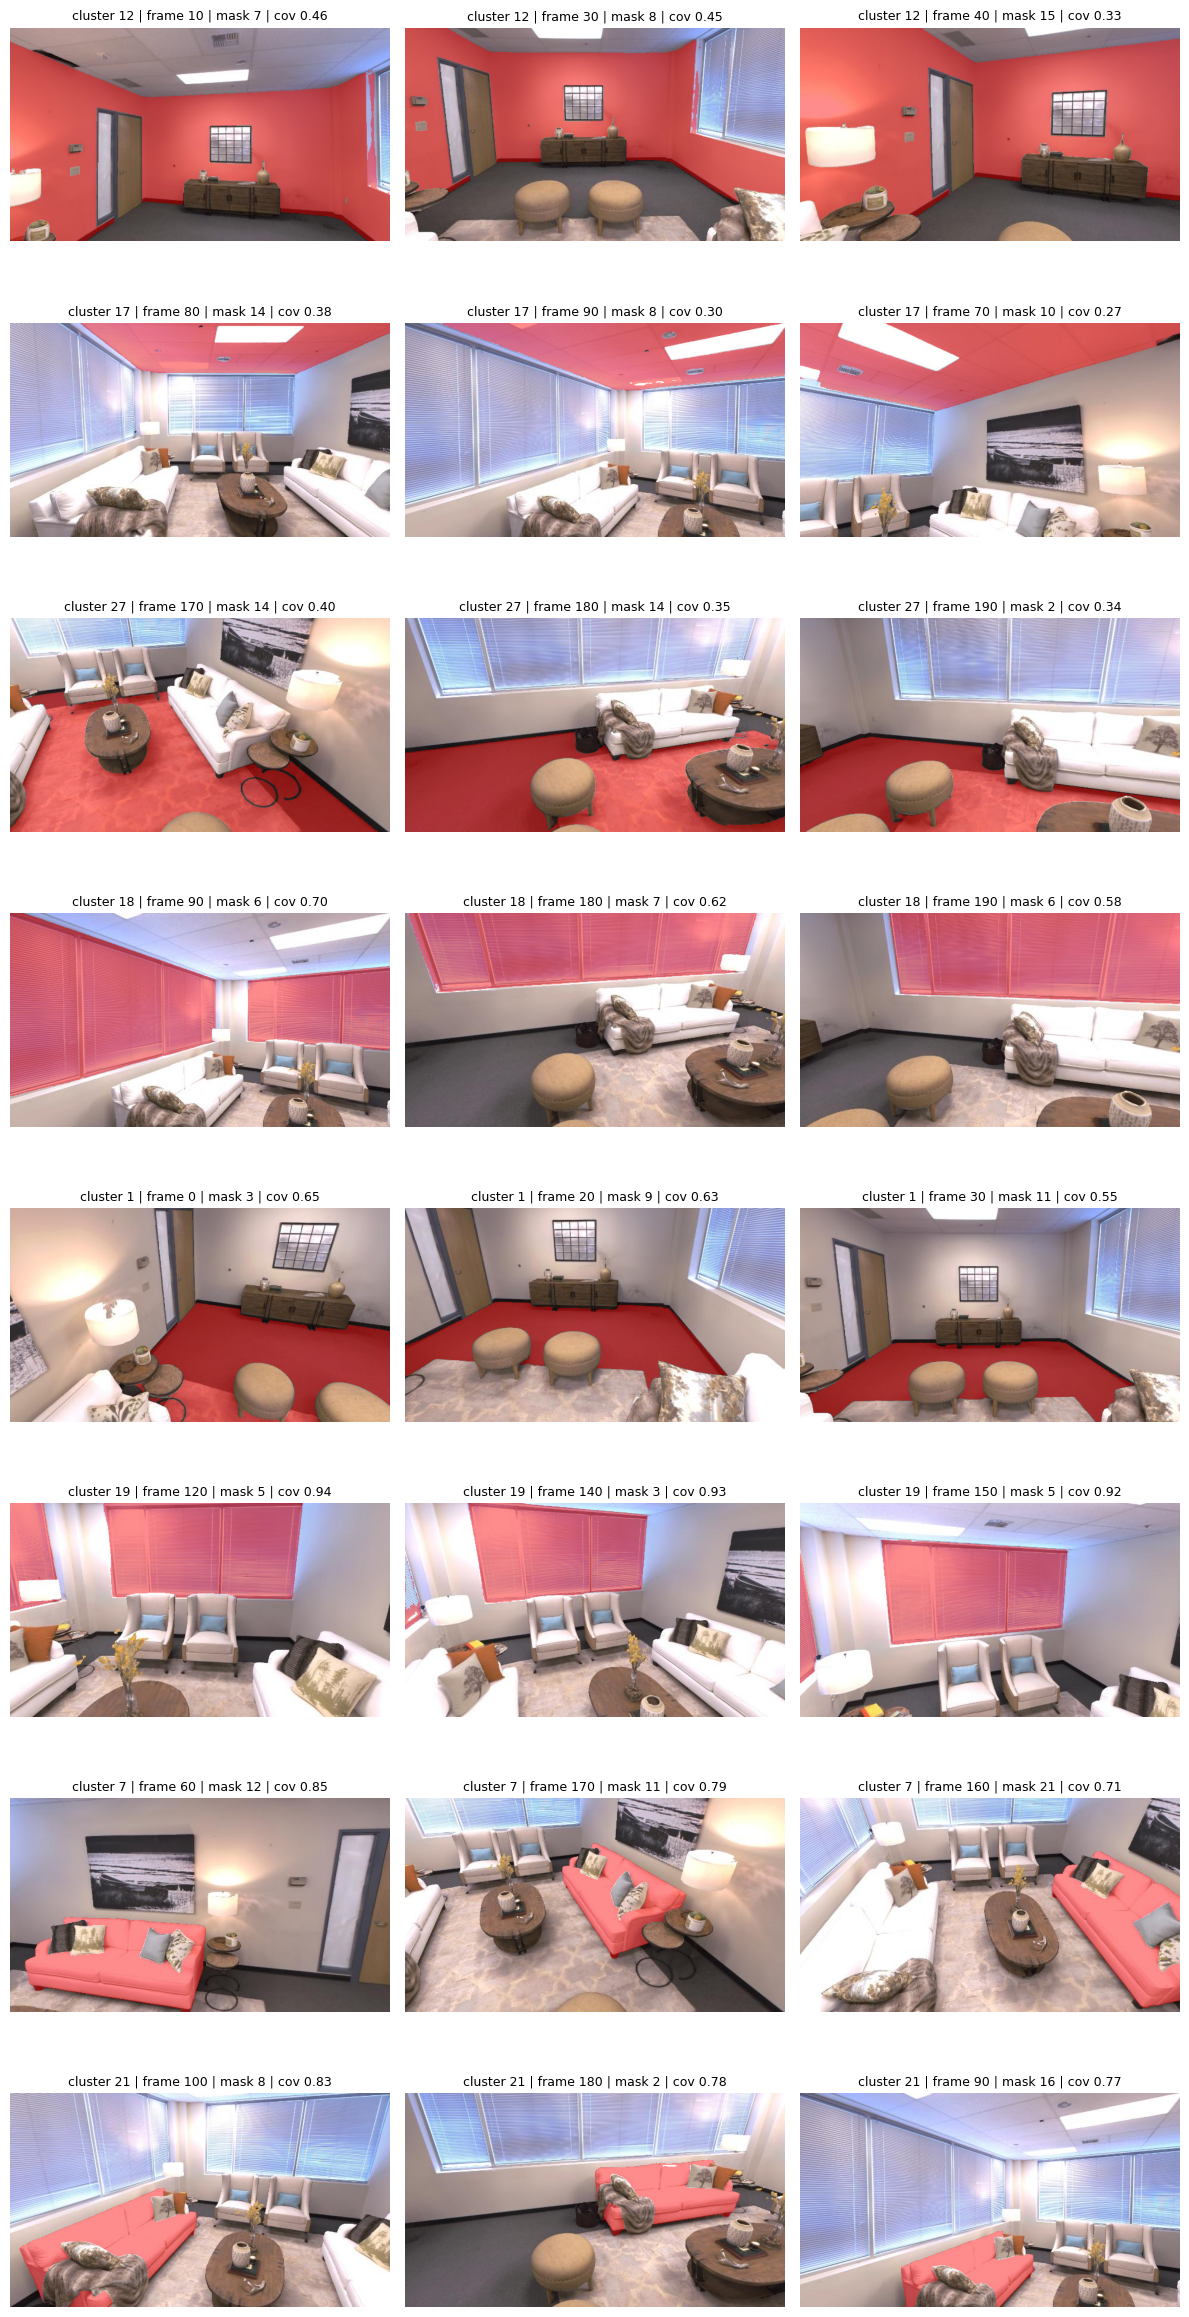

In [5]:
import cv2
import matplotlib.pyplot as plt

def overlay_mask(rgb, binary_mask, color=(255, 0, 0), alpha=0.45):
    out = rgb.copy()
    color_arr = np.array(color, dtype=np.uint8)
    out[binary_mask] = (alpha * color_arr + (1 - alpha) * out[binary_mask]).astype(np.uint8)
    return out

top_k_clusters = 8
max_views_per_cluster = 3
top_clusters = cluster_summary.head(top_k_clusters)["cluster_id"].tolist()

fig, axes = plt.subplots(len(top_clusters), max_views_per_cluster, figsize=(4 * max_views_per_cluster, 3 * len(top_clusters)))
if len(top_clusters) == 1:
    axes = np.array([axes])

for row_idx, cluster_id in enumerate(top_clusters):
    info = object_dict[cluster_id]
    reps = info["repre_mask_list"][:max_views_per_cluster]
    for col_idx in range(max_views_per_cluster):
        ax = axes[row_idx, col_idx]
        ax.axis("off")
        if col_idx >= len(reps):
            continue
        frame_id, mask_id, coverage = reps[col_idx]
        rgb_path = SCENE_ROOT / "color" / f"{frame_id}.jpg"
        mask_path = MASK_DIR / f"{frame_id}.png"
        rgb = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
        mask_map = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        shown = overlay_mask(rgb, mask_map == mask_id)
        ax.imshow(shown)
        ax.set_title(f"cluster {cluster_id} | frame {frame_id} | mask {mask_id} | cov {coverage:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Export 3D visualization

This writes a PyViz3D scene that can be opened from the generated output folder. It shows the clustered 3D points colored by predicted instance.

In [6]:
vis_dir = BASELINE_DIR / "pyviz3d_room0_clusters"
env = os.environ.copy()
env["PYTHONPATH"] = str(MASKCLUSTERING_ROOT) + os.pathsep + env.get("PYTHONPATH", "")
env["VIS_OUTPUT_DIR"] = str(vis_dir)

cmd = [
    sys.executable, "-m", "visualize.vis_scene",
    "--config", CONFIG,
    "--seq_name", SCENE,
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=MASKCLUSTERING_ROOT, env=env, text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"Visualization failed with exit code {result.returncode}")

print("3D visualization written to:", vis_dir)

Running: /rhome/flowis153/miniconda3/envs/maskclustering/bin/python -m visualize.vis_scene --config replica --seq_name room0

************************************************************************
1) Start local server:
    cd /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0/pyviz3d_room0_clusters; python -m http.server 6008
2) Open in browser:
    http://localhost:6008
************************************************************************

3D visualization written to: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0/pyviz3d_room0_clusters


## 7. Class-agnostic AP for room0

The evaluation script evaluates all `.npz` files in a prediction directory. To avoid accidentally evaluating stale outputs from other scenes, this cell creates a temporary room0-only prediction directory.

In [8]:
eval_pred_dir = BASELINE_DIR / "pred_room0_class_agnostic"
eval_pred_dir.mkdir(parents=True, exist_ok=True)
shutil.copy2(pred_path, eval_pred_dir / f"{SCENE}.npz")

eval_output = BASELINE_DIR / "room0_class_agnostic_ap.txt"
cmd = [
    sys.executable, "-m", "evaluation.evaluate",
    "--pred_path", str(eval_pred_dir),
    "--gt_path", str(DATA_ROOT / "ground_truth"),
    "--dataset", CONFIG,
    "--no_class",
    "--output_file", str(eval_output),
]

print("Running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=REPO_ROOT, env=env, text=True, capture_output=True)
print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"Class-agnostic evaluation failed with exit code {result.returncode}")

print("Saved AP results to:", eval_output)

# Cleaner display for class-agnostic evaluation.
# In --no_class mode, the evaluator maps all GT instances to the first Replica class
# ("basket"). That row is the class-agnostic score, not an actual basket-only score.
import pandas as pd
import numpy as np

eval_df = pd.read_csv(eval_output)

metric_rows = eval_df[eval_df["class"] == "basket"].copy()
if metric_rows.empty:
    raise RuntimeError("Could not find class-agnostic metric row. Expected dummy class 'basket'.")

row = metric_rows.iloc[0]

summary = pd.DataFrame([
    {
        "scene": SCENE,
        "evaluation": "class_agnostic",
        "AP": row["ap"],
        "AP_50": row["ap50"],
        "AP_25": row["ap25"],
        "note": "All classes are merged into one dummy class by --no_class.",
    }
])

display(summary)

print()
print("Why are many rows NaN?")
print(
    "This is expected: with --no_class, all ground-truth instances are mapped "
    "to one dummy class ('basket'). The other class rows are not evaluated."
)

print()
print("Raw evaluator output:")
display(eval_df)

Running: /rhome/flowis153/miniconda3/envs/maskclustering/bin/python -m evaluation.evaluate --pred_path /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0/pred_room0_class_agnostic --gt_path /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/ground_truth --dataset replica --no_class --output_file /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone 1/outputs/maskclustering_baseline_room0/room0_class_agnostic_ap.txt
start evaluating: pred_room0_class_agnostic
evaluating 1 scans...

scans processed: 1
################################################################
what           :             AP         AP_50%         AP_25%
################################################################
basket         :          0.149          0.305          0.489
----------------------------------------------------------------
average        :          0.149          0.305          0.489

save resu

,scene,evaluation,AP,AP_50,AP_25,note
0,room0,class_agnostic,0.149119,0.305243,0.489386,All classes are merged into one dummy class by...



Why are many rows NaN?
This is expected: with --no_class, all ground-truth instances are mapped to one dummy class ('basket'). The other class rows are not evaluated.

Raw evaluator output:


,class,class id,ap,ap50,ap25
0,basket,3.000000,0.149119,0.305243,0.489386
1,bed,7.000000,NaN,NaN,NaN
2,bench,8.000000,NaN,NaN,NaN
3,bin,10.000000,NaN,NaN,NaN
4,blanket,11.000000,NaN,NaN,NaN
5,blinds,12.000000,NaN,NaN,NaN
6,book,13.000000,NaN,NaN,NaN
7,bottle,14.000000,NaN,NaN,NaN
8,box,15.000000,NaN,NaN,NaN
9,bowl,16.000000,NaN,NaN,NaN


## 8. Optional: semantic AP

Only run this once semantic labels have been assigned to the clusters. The original pipeline does that with CLIP/Open-Vocabulary features; later in our project this can be replaced or complemented by Qwen3-VL scores/labels.

If `data/prediction/replica/room0.npz` does not exist yet, semantic AP is not ready.

In [9]:
semantic_pred_path = REPO_ROOT / "data" / "prediction" / CONFIG / f"{SCENE}.npz"

if not semantic_pred_path.exists():
    print("Semantic prediction not found yet:", semantic_pred_path)
    print("That is expected at this stage. First produce semantic labels per cluster, then rerun this cell.")
else:
    eval_sem_dir = BASELINE_DIR / "pred_room0_semantic"
    eval_sem_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(semantic_pred_path, eval_sem_dir / f"{SCENE}.npz")

    semantic_eval_output = BASELINE_DIR / "room0_semantic_ap.txt"
    cmd = [
        sys.executable, "-m", "evaluation.evaluate",
        "--pred_path", str(eval_sem_dir),
        "--gt_path", str(DATA_ROOT / "ground_truth"),
        "--dataset", CONFIG,
        "--output_file", str(semantic_eval_output),
    ]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=REPO_ROOT, env=env, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Semantic evaluation failed with exit code {result.returncode}")

    print("Saved semantic AP results to:", semantic_eval_output)
    print(semantic_eval_output.read_text())

Semantic prediction not found yet: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/prediction/replica/room0.npz
That is expected at this stage. First produce semantic labels per cluster, then rerun this cell.


## 9. Export pairwise view-consensus scores for the poster

This uses the initial mask graph retained in `nodes` and exports only mask pairs that belong to the same final baseline cluster. Run this cell in the same kernel session as the graph-construction cell (Section 3).

In [ ]:
from itertools import combinations

if 'nodes' not in globals():
    raise RuntimeError(
        'The initial graph nodes are not in memory. Run the graph-construction '
        'cell in Section 3 first, then execute this cell.'
    )

node_by_mask = {
    (int(node.mask_list[0][0]), int(node.mask_list[0][1])): node
    for node in nodes
    if len(node.mask_list) == 1
}

consensus_rows = []
missing_masks = set()
for cluster_id, info in object_dict.items():
    cluster_masks = list(dict.fromkeys(
        (int(entry[0]), int(entry[1])) for entry in info.get('mask_list', [])
    ))
    for (frame_a, mask_a), (frame_b, mask_b) in combinations(cluster_masks, 2):
        node_a = node_by_mask.get((frame_a, mask_a))
        node_b = node_by_mask.get((frame_b, mask_b))
        if node_a is None or node_b is None:
            missing_masks.update(
                mask for mask, node in [
                    ((frame_a, mask_a), node_a), ((frame_b, mask_b), node_b)
                ] if node is None
            )
            continue
        num_observers = float(torch.dot(
            node_a.visible_frame, node_b.visible_frame
        ).item())
        num_supporters = float(torch.dot(
            node_a.contained_mask, node_b.contained_mask
        ).item())
        view_consensus_score = (
            num_supporters / num_observers if num_observers > 0 else 0.0
        )
        consensus_rows.append({
            'cluster_id': int(cluster_id),
            'frame_a': frame_a, 'mask_a': mask_a,
            'frame_b': frame_b, 'mask_b': mask_b,
            'num_observers': num_observers,
            'num_supporters': num_supporters,
            'view_consensus_score': view_consensus_score,
        })

view_consensus_df = pd.DataFrame(consensus_rows)
view_consensus_path = BASELINE_DIR / f'{SCENE}_view_consensus_pairs.csv'
view_consensus_df.to_csv(view_consensus_path, index=False)
print('Saved:', view_consensus_path)
print('Exported pairs:', len(view_consensus_df))
print('Final masks without retained initial node:', len(missing_masks))
display(view_consensus_df.head())